In [1]:
# Install and import all required libraries
!pip install pandas numpy matplotlib seaborn faker -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from faker import Faker
import random
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
fake = Faker()

print("All libraries imported successfully!")
print("Let's build a People Analytics Dashboard!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.0 MB/s eta 0:00:00
All libraries imported successfully!
Let's build a People Analytics Dashboard!


In [2]:
# Generate People Analytics Dataset
n_employees = 1470

departments = ['Engineering', 'Sales', 'Marketing', 'HR', 'Finance',
               'Operations', 'Product', 'Customer Success']
job_levels = ['Junior', 'Mid', 'Senior', 'Lead', 'Manager', 'Director', 'VP']
education = ['High School', 'Bachelor', 'Master', 'PhD']
performance_ratings = ['Needs Improvement', 'Meets Expectations',
                       'Exceeds Expectations', 'Outstanding']
attrition_reasons = ['Better Opportunity', 'Compensation', 'Work-Life Balance',
                     'Career Growth', 'Relocation', 'Personal']
locations = ['Austin TX', 'San Francisco CA', 'New York NY',
             'Seattle WA', 'Chicago IL', 'Boston MA']

employees = []
for i in range(n_employees):
    dept = random.choice(departments)
    level = random.choice(job_levels)
    age = random.randint(22, 58)
    tenure = random.randint(0, 15)

    # Salary based on level
    salary_map = {'Junior': 55000, 'Mid': 75000, 'Senior': 95000,
                  'Lead': 115000, 'Manager': 130000, 'Director': 160000, 'VP': 200000}
    salary = salary_map[level] + random.randint(-10000, 20000)

    # Attrition probability
    attrition_prob = 0.15
    if tenure < 2: attrition_prob += 0.10
    if level == 'Junior': attrition_prob += 0.05
    if salary < 70000: attrition_prob += 0.08

    attrition = 1 if random.random() < attrition_prob else 0

    satisfaction = round(random.uniform(1.0, 5.0), 1)
    engagement = round(random.uniform(1.0, 5.0), 1)
    performance = random.choice(performance_ratings)

    employees.append({
        'employee_id': f'EMP{i+1:05d}',
        'age': age,
        'department': dept,
        'job_level': level,
        'education': random.choice(education),
        'location': random.choice(locations),
        'tenure_years': tenure,
        'salary': salary,
        'performance_rating': performance,
        'satisfaction_score': satisfaction,
        'engagement_score': engagement,
        'attrition': attrition,
        'attrition_reason': random.choice(attrition_reasons) if attrition else None,
        'training_hours': random.randint(0, 80),
        'promotions': random.randint(0, 5),
        'hire_date': fake.date_between(start_date='-15y', end_date='-1m')
    })

hr_df = pd.DataFrame(employees)

total_employees = len(hr_df)
attrition_rate = hr_df['attrition'].mean() * 100
avg_salary = hr_df['salary'].mean()
avg_tenure = hr_df['tenure_years'].mean()
avg_satisfaction = hr_df['satisfaction_score'].mean()

print(f"Dataset generated successfully!")
print(f"Total employees: {total_employees:,}")
print(f"Attrition rate: {attrition_rate:.2f}%")
print(f"Average salary: ${avg_salary:,.0f}")
print(f"Average tenure: {avg_tenure:.1f} years")
print(f"Average satisfaction: {avg_satisfaction:.2f}/5.0")
print(f"\nDepartment breakdown:")
print(hr_df['department'].value_counts())

Dataset generated successfully!
Total employees: 1,470
Attrition rate: 17.96%
Average salary: $123,394
Average tenure: 7.3 years
Average satisfaction: 3.01/5.0

Department breakdown:
department
Marketing           199
Engineering         188
Finance             186
Sales               184
Operations          183
Product             182
Customer Success    178
HR                  170
Name: count, dtype: int64


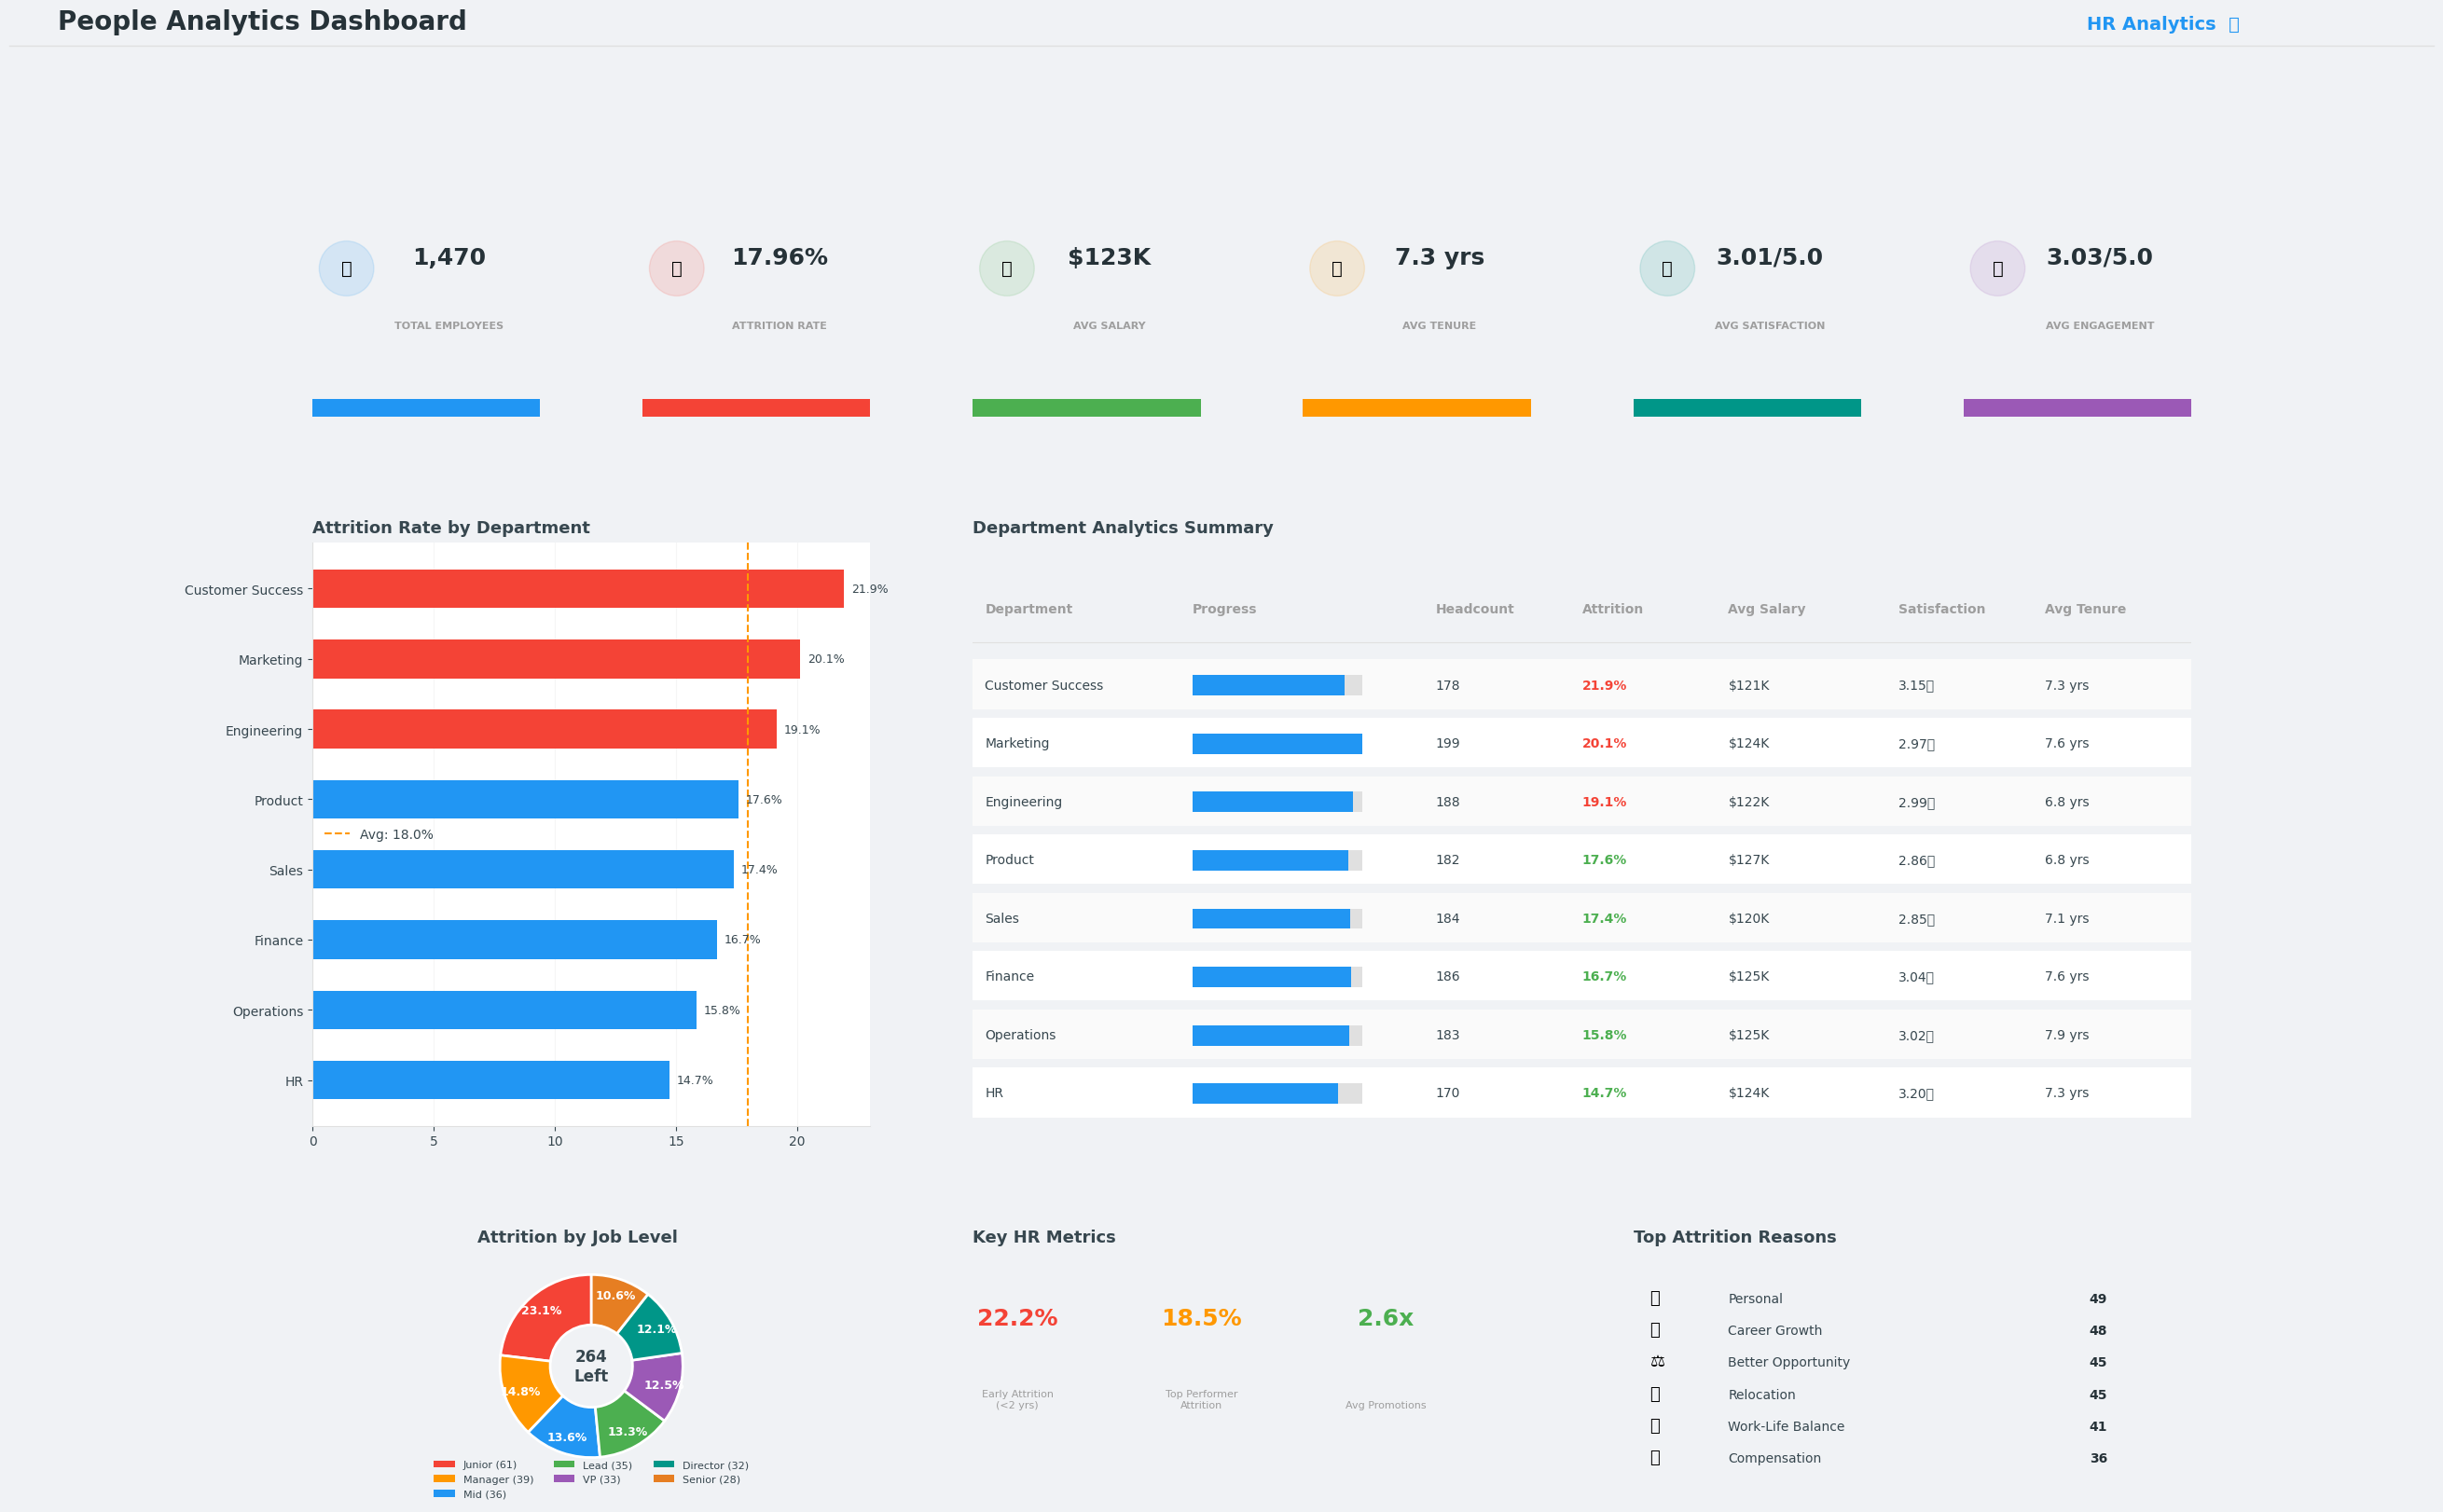

People Analytics Dashboard created!


In [3]:
# People Analytics Dashboard - Klipfolio Style
plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
})

plt.style.use('default')
fig = plt.figure(figsize=(26, 18))
fig.patch.set_facecolor('#f0f2f5')
gs = gridspec.GridSpec(4, 6, figure=fig, hspace=0.55, wspace=0.45)

BLUE = '#2196F3'
GREEN = '#4CAF50'
RED = '#f44336'
GRAY = '#9e9e9e'
DARK = '#263238'
LIGHT = '#ffffff'
BORDER = '#e0e0e0'
TEXT = '#37474f'
ORANGE = '#FF9800'
PURPLE = '#9b59b6'
TEAL = '#009688'

def card(ax):
    ax.set_facecolor(LIGHT)
    for spine in ax.spines.values():
        spine.set_color(BORDER)
        spine.set_linewidth(0.8)

# ── HEADER ─────────────────────────────────────────
fig.text(0.02, 0.975, 'People Analytics Dashboard',
         ha='left', fontsize=20, fontweight='bold', color=DARK)
fig.text(0.92, 0.975, 'HR Analytics  👥',
         ha='right', fontsize=14, fontweight='bold', color=BLUE)
fig.add_artist(plt.Line2D([0.0, 1.0], [0.965, 0.965],
               color=BORDER, linewidth=1.0, transform=fig.transFigure))

# ── TOP ROW: KPI Cards ──────────────────────────────
kpi_data = [
    ('TOTAL EMPLOYEES', f'{total_employees:,}', BLUE, '👥'),
    ('ATTRITION RATE', f'{attrition_rate:.2f}%', RED, '📉'),
    ('AVG SALARY', f'${avg_salary/1e3:.0f}K', GREEN, '💰'),
    ('AVG TENURE', f'{avg_tenure:.1f} yrs', ORANGE, '📅'),
    ('AVG SATISFACTION', f'{avg_satisfaction:.2f}/5.0', TEAL, '⭐'),
    ('AVG ENGAGEMENT', f'{hr_df["engagement_score"].mean():.2f}/5.0', PURPLE, '🎯'),
]

for idx, (label, value, color, icon) in enumerate(kpi_data):
    ax_kpi = fig.add_subplot(gs[0, idx])
    card(ax_kpi)
    ax_kpi.axis('off')
    circle = plt.Circle((0.15, 0.65), 0.12, color=color + '22',
                        transform=ax_kpi.transAxes, zorder=2)
    ax_kpi.add_patch(circle)
    ax_kpi.text(0.15, 0.65, icon, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=14)
    ax_kpi.text(0.60, 0.70, value, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=18,
                fontweight='bold', color=DARK)
    ax_kpi.text(0.60, 0.40, label, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=8,
                color=GRAY, fontweight='bold')
    ax_kpi.add_patch(mpatches.FancyBboxPatch((0.0, 0.0), 1.0, 0.08,
                      boxstyle="square,pad=0", facecolor=color,
                      edgecolor='none', transform=ax_kpi.transAxes))

# ── LEFT: Attrition by Department (Horizontal bars) ─
ax1 = fig.add_subplot(gs[1:3, 0:2])
card(ax1)
ax1.set_title('Attrition Rate by Department', color=TEXT,
              fontweight='bold', fontsize=13, loc='left', pad=8)
dept_attrition = hr_df.groupby('department')['attrition'].mean() * 100
dept_attrition = dept_attrition.sort_values()
colors1 = [RED if v > attrition_rate else BLUE for v in dept_attrition.values]
bars1 = ax1.barh(dept_attrition.index, dept_attrition.values,
                 color=colors1, edgecolor='none', height=0.55)
ax1.axvline(attrition_rate, color=ORANGE, linestyle='--',
            linewidth=1.5, label=f'Avg: {attrition_rate:.1f}%')
ax1.tick_params(colors=TEXT, labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color(BORDER)
ax1.spines['left'].set_color(BORDER)
ax1.grid(axis='x', color='#f5f5f5', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.legend(fontsize=10, frameon=False, labelcolor=TEXT)
for bar, val in zip(bars1, dept_attrition.values):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, color=TEXT)

# ── CENTER: Employee Data Table ─────────────────────
ax2 = fig.add_subplot(gs[1:3, 2:6])
card(ax2)
ax2.axis('off')
ax2.set_title('Department Analytics Summary', color=TEXT,
              fontweight='bold', fontsize=13, loc='left', pad=8)

dept_stats = hr_df.groupby('department').agg(
    headcount=('employee_id', 'count'),
    attrition_rate=('attrition', 'mean'),
    avg_salary=('salary', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_tenure=('tenure_years', 'mean'),
    avg_engagement=('engagement_score', 'mean')
).reset_index().sort_values('attrition_rate', ascending=False)

headers = ['Department', 'Progress', 'Headcount', 'Attrition',
           'Avg Salary', 'Satisfaction', 'Avg Tenure']
col_x = [0.01, 0.18, 0.38, 0.50, 0.62, 0.76, 0.88]
for i, h in enumerate(headers):
    ax2.text(col_x[i], 0.88, h, transform=ax2.transAxes,
             fontsize=10, color=GRAY, fontweight='bold')
ax2.plot([0, 1], [0.83, 0.83], color=BORDER,
         linewidth=0.8, transform=ax2.transAxes)

for ridx, row in dept_stats.iterrows():
    y = 0.75 - list(dept_stats.index).index(ridx) * 0.10
    ax2.add_patch(mpatches.FancyBboxPatch((0.0, y-0.035), 1.0, 0.085,
                   boxstyle="square,pad=0",
                   facecolor='#fafafa' if list(dept_stats.index).index(ridx) % 2 == 0 else '#ffffff',
                   edgecolor='none', transform=ax2.transAxes))
    ax2.text(col_x[0], y, row['department'], transform=ax2.transAxes,
             fontsize=10, color=TEXT)
    prog = row['headcount'] / dept_stats['headcount'].max()
    ax2.add_patch(mpatches.FancyBboxPatch((col_x[1], y-0.012), 0.14, 0.035,
                   boxstyle="square,pad=0", facecolor='#e0e0e0',
                   edgecolor='none', transform=ax2.transAxes))
    ax2.add_patch(mpatches.FancyBboxPatch((col_x[1], y-0.012), 0.14*prog, 0.035,
                   boxstyle="square,pad=0", facecolor=BLUE,
                   edgecolor='none', transform=ax2.transAxes))
    ax2.text(col_x[2], y, f'{row["headcount"]:,}', transform=ax2.transAxes,
             fontsize=10, color=TEXT)
    attr_color = RED if row['attrition_rate'] > 0.18 else GREEN
    ax2.text(col_x[3], y, f'{row["attrition_rate"]*100:.1f}%',
             transform=ax2.transAxes, fontsize=10,
             color=attr_color, fontweight='bold')
    ax2.text(col_x[4], y, f'${row["avg_salary"]/1e3:.0f}K',
             transform=ax2.transAxes, fontsize=10, color=TEXT)
    ax2.text(col_x[5], y, f'{row["avg_satisfaction"]:.2f}⭐',
             transform=ax2.transAxes, fontsize=10, color=TEXT)
    ax2.text(col_x[6], y, f'{row["avg_tenure"]:.1f} yrs',
             transform=ax2.transAxes, fontsize=10, color=TEXT)

# ── BOTTOM LEFT: Attrition by Job Level Donut ──────
ax3 = fig.add_subplot(gs[3, 0:2])
card(ax3)
ax3.set_title('Attrition by Job Level', color=TEXT,
              fontweight='bold', fontsize=13, loc='left', pad=8)
level_attrition = hr_df[hr_df['attrition']==1]['job_level'].value_counts()
donut_colors = [RED, ORANGE, BLUE, GREEN, PURPLE, TEAL, '#e67e22']
wedges, texts, autotexts = ax3.pie(
    level_attrition.values,
    colors=donut_colors[:len(level_attrition)],
    autopct='%1.1f%%', startangle=90, pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.55}
)
for text in texts:
    text.set_visible(False)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
ax3.text(0, 0, f'{hr_df["attrition"].sum()}\nLeft', ha='center',
         va='center', fontsize=12, fontweight='bold', color=TEXT)
ax3.legend(handles=[mpatches.Patch(facecolor=donut_colors[i],
           label=f'{level_attrition.index[i]} ({level_attrition.values[i]})')
           for i in range(len(level_attrition))],
           loc='lower center', ncol=3, fontsize=8,
           frameon=False, labelcolor=TEXT, bbox_to_anchor=(0.5, -0.12))

# ── BOTTOM CENTER: Key HR Metrics ──────────────────
ax4 = fig.add_subplot(gs[3, 2:4])
card(ax4)
ax4.axis('off')
ax4.set_title('Key HR Metrics', color=TEXT,
              fontweight='bold', fontsize=13, loc='left', pad=8)
metrics = [
    (f'{hr_df[hr_df["tenure_years"]<2]["attrition"].mean()*100:.1f}%', 'Early Attrition\n(<2 yrs)'),
    (f'{hr_df[hr_df["performance_rating"]=="Outstanding"]["attrition"].mean()*100:.1f}%', 'Top Performer\nAttrition'),
    (f'{hr_df["promotions"].mean():.1f}x', 'Avg Promotions'),
]
for idx, (val, label) in enumerate(metrics):
    x = 0.08 + idx * 0.33
    color = RED if idx == 0 else ORANGE if idx == 1 else GREEN
    ax4.text(x, 0.68, val, transform=ax4.transAxes,
             fontsize=18, fontweight='bold', color=color, ha='center')
    ax4.text(x, 0.32, label, transform=ax4.transAxes,
             fontsize=8, color=GRAY, ha='center')

# ── BOTTOM RIGHT: Attrition Reasons ────────────────
ax5 = fig.add_subplot(gs[3, 4:6])
card(ax5)
ax5.axis('off')
ax5.set_title('Top Attrition Reasons', color=TEXT,
              fontweight='bold', fontsize=13, loc='left', pad=8)
reasons = hr_df[hr_df['attrition']==1]['attrition_reason'].value_counts()
icons = ['💼', '💵', '⚖️', '📈', '🏠', '👤']
for idx, (reason, val) in enumerate(reasons.items()):
    y = 0.78 - idx * 0.14
    ax5.text(0.03, y, icons[idx], transform=ax5.transAxes, fontsize=13)
    ax5.text(0.17, y, reason, transform=ax5.transAxes, fontsize=10, color=TEXT)
    ax5.text(0.85, y, f'{val:,}', transform=ax5.transAxes,
             fontsize=10, color=DARK, fontweight='bold', ha='right')

plt.savefig('people_analytics_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#f0f2f5')
plt.show()
print("People Analytics Dashboard created!")

In [6]:
from google.colab import files

# Save dataset
hr_df.to_csv('people_analytics_data.csv', index=False)

# Save README
results = """
# People Analytics Dashboard

## Workforce Overview
- **Total Employees:** {:,}
- **Attrition Rate:** {:.2f}%
- **Average Salary:** ${:,.0f}
- **Average Tenure:** {:.1f} years
- **Average Satisfaction:** {:.2f}/5.0
- **Average Engagement:** {:.2f}/5.0

## Dashboard Sections
1. Attrition Rate by Department — Horizontal Bar Chart
2. Department Analytics Summary — Data Table
3. Attrition by Job Level — Donut Chart
4. Key HR Metrics — Early Attrition, Top Performer Attrition, Avg Promotions
5. Top Attrition Reasons — Ranked List

## Key Insights
- Overall attrition rate: {:.2f}%
- Highest attrition department: {}
- Most common attrition reason: {}
- High risk tenure group: <2 years

## Technologies
- Python, Pandas, NumPy
- Matplotlib, Seaborn
- Google Colab (T4 GPU)

## Dataset
- 1,470 employee records
- 8 departments
- 7 job levels
- 6 locations
""".format(
    total_employees,
    attrition_rate,
    avg_salary,
    avg_tenure,
    avg_satisfaction,
    hr_df['engagement_score'].mean(),
    attrition_rate,
    hr_df.groupby('department')['attrition'].mean().idxmax(),
    hr_df[hr_df['attrition']==1]['attrition_reason'].value_counts().index[0]
)

with open('README_results.md', 'w') as f:
    f.write(results)

print("Downloading files...")
files.download('people_analytics_dashboard.png')
files.download('people_analytics_data.csv')
files.download('README_results.md')
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
